# Static findings figures — Objectives I & II

MSc Data Science · Universidad ICESI · Davinson Arteaga & Gian Mendoza

Publication-ready static figures answering the two main project objectives. 8 figures + 1 headline.

**Outputs:** PNG files at 150 DPI saved to `/media/volume/jay2vol/nexgddp/outputs/figures/`.

## Setup

In [1]:
import sys
import warnings
from pathlib import Path
from functools import lru_cache

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd()))
import analysis_lib as al

In [2]:
BASE_DIR = Path('/media/volume/jay2vol/nexgddp')
PROC_DIR = BASE_DIR / 'processed'
SPATIAL_TRENDS_DIR = BASE_DIR / 'outputs' / '10_spatial_trends'
FIG_OUT = BASE_DIR / 'outputs' / 'figures'
FIG_OUT.mkdir(parents=True, exist_ok=True)

df_annual = pd.concat([
    pd.read_csv(PROC_DIR / 'annual_subregion_anomalies.csv'),
    pd.read_csv(PROC_DIR / 'annual_continental_anomalies.csv'),
], ignore_index=True)
df_monthly = pd.read_csv(PROC_DIR / 'monthly_subregion_anomalies.csv')

MODELS = sorted(df_annual['model'].unique())
SCENARIOS = sorted(df_annual['scenario'].unique())
SUBREGIONS = sorted(df_annual['subregion'].unique())
SUBREGIONS_MONTHLY = [s for s in SUBREGIONS if 'continental' not in s.lower()]

SUBREGION_4 = ['Northern Tropics', 'Central Amazonia', 'Subtropical Andes', 'Southern Cone']
SUBREGION_4 = [s for s in SUBREGION_4 if s in SUBREGIONS_MONTHLY]
SCENARIO_ORDER = ['historical', 'ssp126', 'ssp245', 'ssp370', 'ssp585']
SCENARIO_ORDER = [s for s in SCENARIO_ORDER if s in SCENARIOS]
FUTURE_SCENARIOS = [s for s in SCENARIO_ORDER if s != 'historical']

SCENARIO_COLORS = {'historical': '#333333', 'ssp126': '#1f77b4', 'ssp245': '#daa520', 'ssp370': '#ff7f0e', 'ssp585': '#d62728'}
SCENARIO_LABELS = {'historical': 'Historical', 'ssp126': 'SSP1-2.6', 'ssp245': 'SSP2-4.5', 'ssp370': 'SSP3-7.0', 'ssp585': 'SSP5-8.5'}

SUBREGION_BOXES = {
    'Northern Tropics':   {'lon': (-82, -34), 'lat': (-5, 13),    'color': '#e41a1c'},
    'Central Amazonia':   {'lon': (-70, -50), 'lat': (-15, -5),   'color': '#377eb8'},
    'Subtropical Andes':  {'lon': (-75, -65), 'lat': (-35, -15),  'color': '#4daf4a'},
    'Southern Cone':      {'lon': (-82, -34), 'lat': (-56, -35),  'color': '#984ea3'},
}

SA_EXTENT = (-82, -34, -56, 13)
BASELINE_PERIOD = (1960, 2014)

print(f'Models: {len(MODELS)} · Scenarios: {len(SCENARIOS)} · Subregions: {len(SUBREGIONS)}')
print(f'Output: {FIG_OUT}')

Models: 8 · Scenarios: 5 · Subregions: 5
Output: /media/volume/jay2vol/nexgddp/outputs/figures


In [3]:
@lru_cache(maxsize=64)
def _load_spatial_field(variable, window_key, scenario):
    if window_key == 'historical_1950_2014':
        label = f'{variable}__{window_key}'
    else:
        label = f'{variable}__{window_key}__{scenario}'
    slope_path = SPATIAL_TRENDS_DIR / f'sen_slope_{label}.nc'
    pval_path = SPATIAL_TRENDS_DIR / f'mk_pvalue_{label}.nc'
    if not slope_path.exists():
        return None
    ds_slope = xr.open_dataset(slope_path)
    ds_pval = xr.open_dataset(pval_path)
    out = xr.Dataset({'sen_slope': ds_slope['sen_slope'], 'mk_pvalue': ds_pval['mk_pvalue']})
    if float(out['lon'].max()) > 180:
        out = out.assign_coords(lon=(((out['lon'] + 180) % 360) - 180)).sortby('lon')
    return out

WINDOW_SPECS = {
    'historical_1950_2014': {'hist': (1950, 2014), 'ssp': None},
    'full_1950_2100':       {'hist': (1950, 2014), 'ssp': (2015, 2100)},
}

def compute_slope_table(variable, window_key='full_1950_2100'):
    rows = []
    spec = WINDOW_SPECS[window_key]
    yr = (spec['hist'][0], spec['ssp'][1]) if (spec['hist'] and spec['ssp']) else (spec['hist'] or spec['ssp'])
    use_hist = spec['hist'] is not None and spec['ssp'] is not None
    for subregion in SUBREGION_4:
        for scenario in SCENARIO_ORDER:
            if scenario == 'historical':
                ens = al.build_annual_series_ensemble(df_annual=df_annual, scenario='historical', variable=variable, subregion=subregion, year_range=(1950, 2014), selected_models=MODELS, use_historical_before_2015=False)
            else:
                ens = al.build_annual_series_ensemble(df_annual=df_annual, scenario=scenario, variable=variable, subregion=subregion, year_range=yr, selected_models=MODELS, use_historical_before_2015=use_hist)
            if len(ens) < 10:
                continue
            r = al.run_mk_full(ens['ens_p50'].values)
            rows.append({'subregion': subregion, 'scenario': scenario, 'slope': r['sen_slope_per_decade'], 'pvalue': r['mk_hr_p']})
    return pd.DataFrame(rows)

def heatmap_slopes(df_slopes, variable, units, title, output_path, cmap_pos='Reds', cmap_neg='Blues'):
    pivot_slope = df_slopes.pivot(index='subregion', columns='scenario', values='slope').reindex(index=SUBREGION_4, columns=SCENARIO_ORDER)
    pivot_pval = df_slopes.pivot(index='subregion', columns='scenario', values='pvalue').reindex(index=SUBREGION_4, columns=SCENARIO_ORDER)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    vals = pivot_slope.values.astype(float)
    abs_max = max(abs(np.nanmin(vals)), abs(np.nanmax(vals)))
    if variable == 'tas':
        cmap = plt.get_cmap('RdBu_r')
    else:
        cmap = plt.get_cmap('RdBu')
    im = ax.imshow(vals, cmap=cmap, vmin=-abs_max, vmax=abs_max, aspect='auto')
    ax.set_xticks(np.arange(len(SCENARIO_ORDER)))
    ax.set_xticklabels([SCENARIO_LABELS[s] for s in SCENARIO_ORDER], fontsize=10)
    ax.set_yticks(np.arange(len(SUBREGION_4)))
    ax.set_yticklabels(SUBREGION_4, fontsize=10)
    for i in range(len(SUBREGION_4)):
        for j in range(len(SCENARIO_ORDER)):
            v = vals[i, j]
            p = pivot_pval.values[i, j]
            if not np.isfinite(v):
                continue
            sign = '+' if v >= 0 else ''
            star = '**' if (np.isfinite(p) and p < 0.01) else ('*' if (np.isfinite(p) and p < 0.05) else '')
            color = 'white' if abs(v) > 0.6 * abs_max else 'black'
            ax.text(j, i, f'{sign}{v:.2f}{star}', ha='center', va='center', fontsize=10, color=color, fontweight='bold')
    cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.03)
    cbar.set_label(f"Sen's slope ({units})", fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold', loc='left')
    ax.text(0.99, -0.18, '`**` p<0.01 · `*` p<0.05', transform=ax.transAxes, ha='right', fontsize=8, style='italic')
    plt.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {output_path}')
    return pivot_slope, pivot_pval

## Figure 1 — Study area and data coverage

South America with the 4 subregion bounding boxes used throughout the analysis. NEX-GDDP-CMIP6 grid resolution: 0.25°.

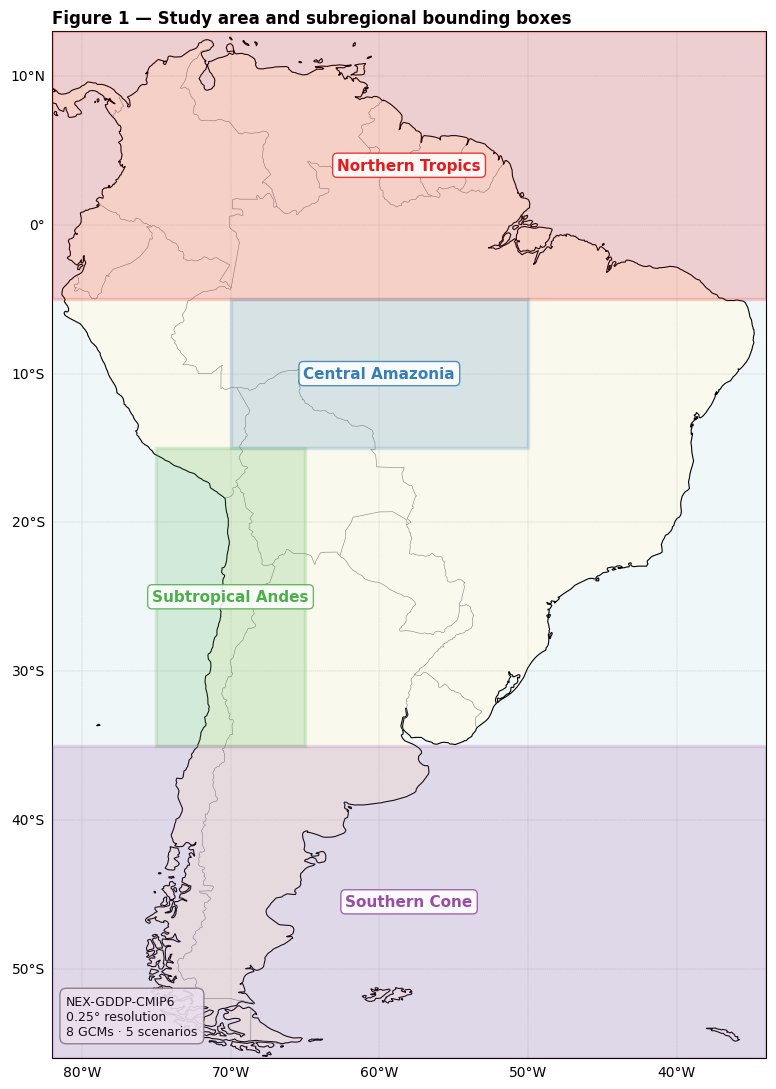

Saved: /media/volume/jay2vol/nexgddp/outputs/figures/fig1_study_area.png


In [4]:
fig1, ax1 = plt.subplots(figsize=(9, 11), subplot_kw={'projection': ccrs.PlateCarree()})
ax1.set_extent(SA_EXTENT, crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.LAND, facecolor='#f5f5dc', alpha=0.5)
ax1.add_feature(cfeature.OCEAN, facecolor='#e0f0f5', alpha=0.5)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
ax1.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor='gray')
gl = ax1.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

for sub_name, box in SUBREGION_BOXES.items():
    lon_min, lon_max = box['lon']
    lat_min, lat_max = box['lat']
    rect = mpatches.Rectangle((lon_min, lat_min), lon_max - lon_min, lat_max - lat_min, linewidth=2.5, edgecolor=box['color'], facecolor=box['color'], alpha=0.18, transform=ccrs.PlateCarree(), zorder=5)
    ax1.add_patch(rect)
    label_lon = (lon_min + lon_max) / 2
    label_lat = (lat_min + lat_max) / 2
    ax1.text(label_lon, label_lat, sub_name, ha='center', va='center', fontsize=11, fontweight='bold', color=box['color'], transform=ccrs.PlateCarree(), zorder=6, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=box['color'], alpha=0.85))

ax1.text(0.02, 0.02, 'NEX-GDDP-CMIP6\n0.25° resolution\n8 GCMs · 5 scenarios', transform=ax1.transAxes, fontsize=9, va='bottom', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))
ax1.set_title('Figure 1 — Study area and subregional bounding boxes', fontsize=12, fontweight='bold', loc='left')
plt.tight_layout()
fig1.savefig(FIG_OUT / 'fig1_study_area.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_OUT / "fig1_study_area.png"}')

## Figure 2 — Temperature scenario divergence

Small multiples 2×2: `tas` anomaly time series 1950–2100 by subregion. Ensemble median + p10–p90 band per scenario.

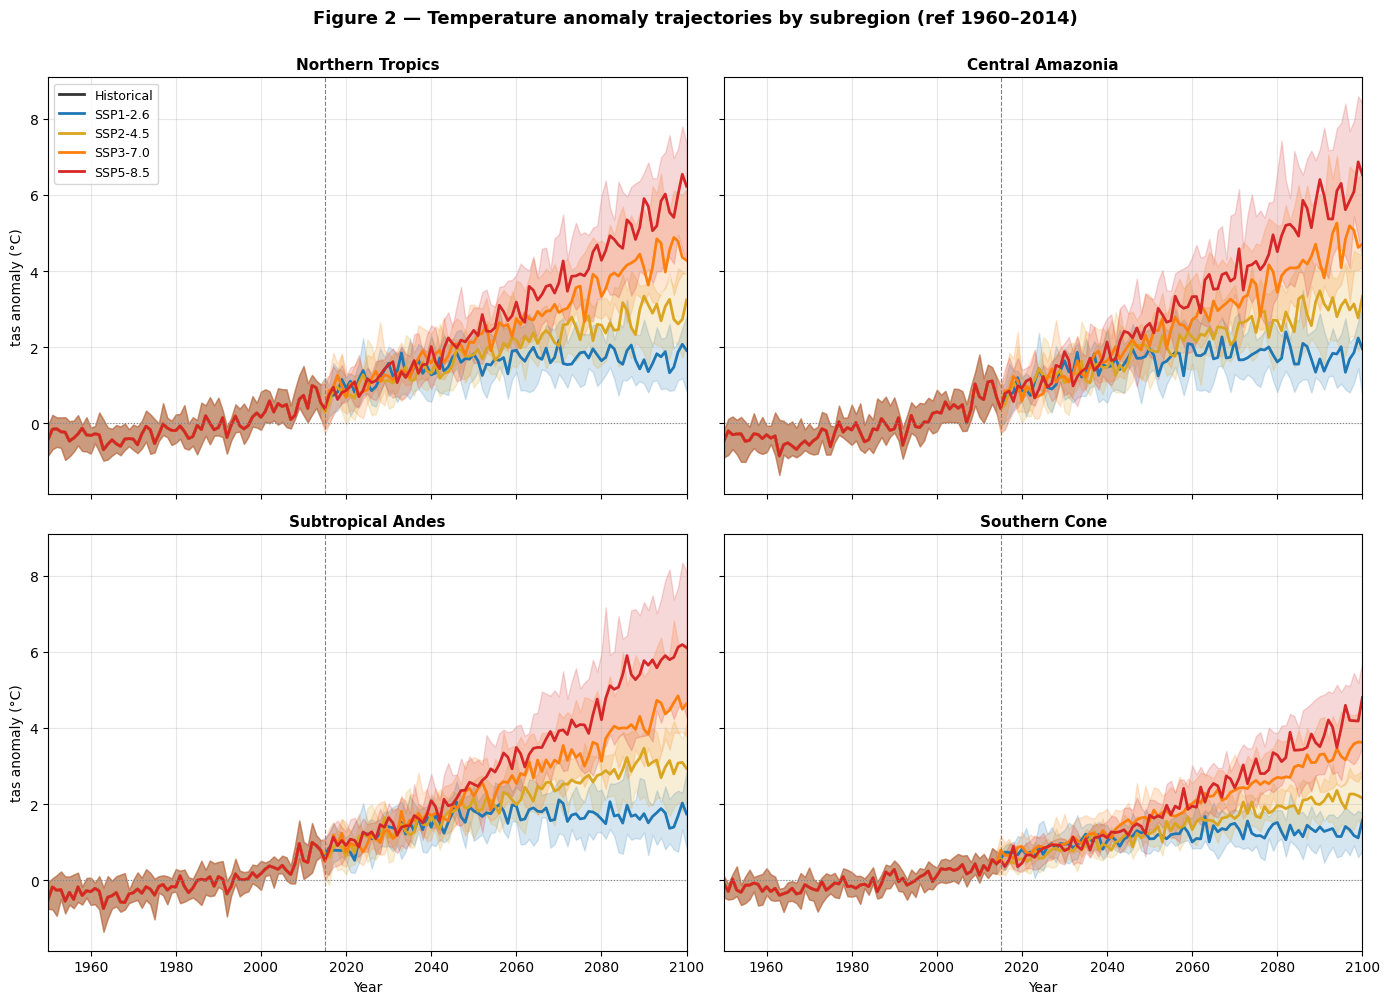

Saved: /media/volume/jay2vol/nexgddp/outputs/figures/fig2_temperature_divergence.png


In [5]:
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

for ax, subregion in zip(axes2.flat, SUBREGION_4):
    for scenario in SCENARIO_ORDER:
        if scenario == 'historical':
            ens = al.build_annual_series_ensemble(df_annual=df_annual, scenario='historical', variable='tas', subregion=subregion, year_range=(1950, 2014), selected_models=MODELS, use_historical_before_2015=False)
        else:
            ens = al.build_annual_series_ensemble(df_annual=df_annual, scenario=scenario, variable='tas', subregion=subregion, year_range=(1950, 2100), selected_models=MODELS, use_historical_before_2015=True)
        if len(ens) == 0:
            continue
        if scenario == 'historical':
            ens = ens[ens['year'] <= 2014]
        color = SCENARIO_COLORS[scenario]
        ax.fill_between(ens['year'], ens['ens_p10'], ens['ens_p90'], color=color, alpha=0.18)
        ax.plot(ens['year'], ens['ens_p50'], color=color, linewidth=2, label=SCENARIO_LABELS[scenario])
    ax.axvline(2015, color='gray', linestyle='--', linewidth=0.8)
    ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
    ax.set_title(subregion, fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.set_xlim(1950, 2100)

for ax in axes2[1, :]:
    ax.set_xlabel('Year', fontsize=10)
for ax in axes2[:, 0]:
    ax.set_ylabel('tas anomaly (°C)', fontsize=10)

axes2[0, 0].legend(loc='upper left', fontsize=9, frameon=True)
fig2.suptitle('Figure 2 — Temperature anomaly trajectories by subregion (ref 1960–2014)', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
fig2.savefig(FIG_OUT / 'fig2_temperature_divergence.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_OUT / "fig2_temperature_divergence.png"}')

## Figure 3 — Temperature Sen's slope heatmap

Subregion × scenario matrix of `tas` trend magnitudes (°C/decade) with Mann-Kendall significance markers.

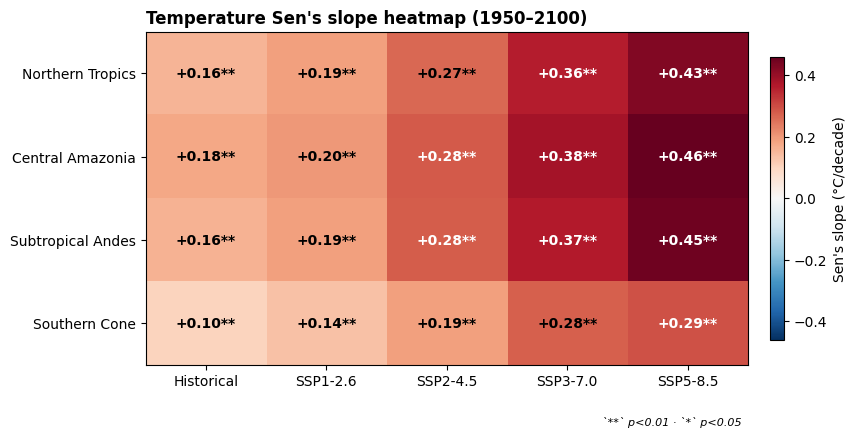

Saved: /media/volume/jay2vol/nexgddp/outputs/figures/fig3_tas_heatmap.png


In [14]:
df_slope_tas = compute_slope_table('tas', 'full_1950_2100')
_, _ = heatmap_slopes(df_slope_tas, 'tas', '°C/decade', 'Temperature Sen\'s slope heatmap (1950–2100)', FIG_OUT / 'fig3_tas_heatmap.png')

## Figure 4 — Spatial temperature trends

Pixel-wise Sen's slope of `tas` for Historical (1950–2014) and SSP5-8.5 full window (1950–2100). Dots = p<0.05.

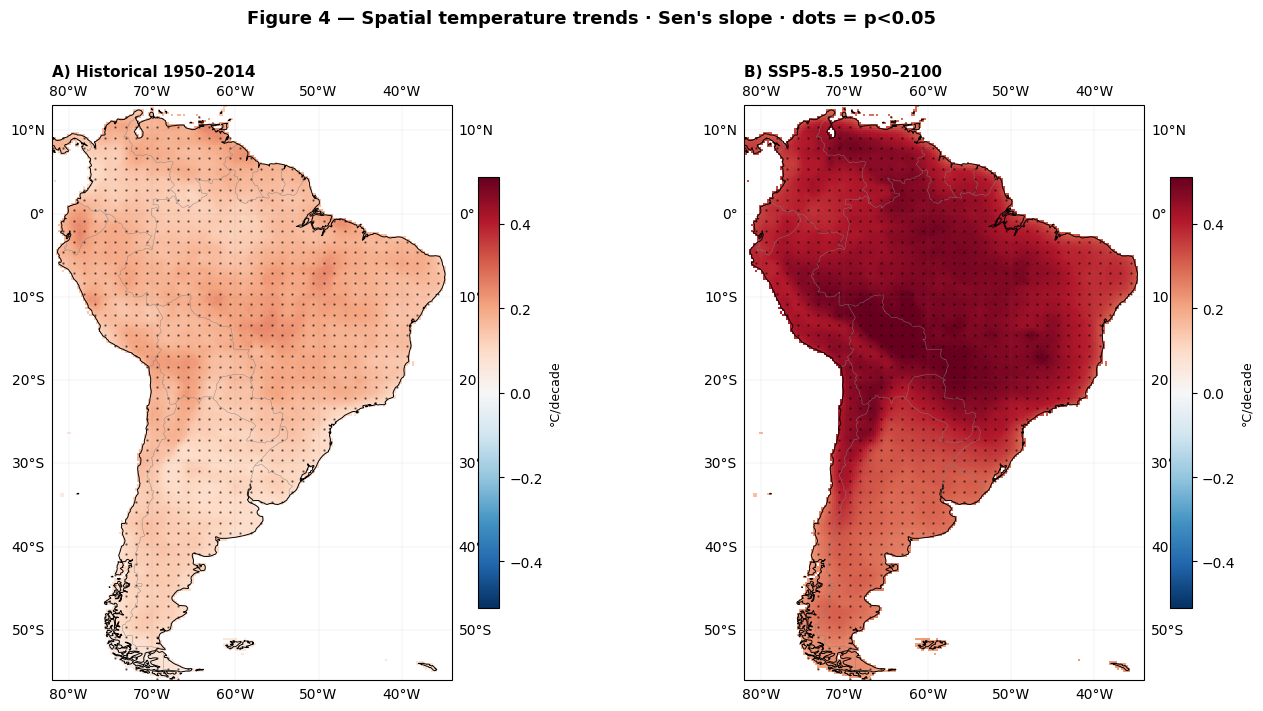

Saved: /media/volume/jay2vol/nexgddp/outputs/figures/fig4_spatial_tas.png


In [7]:
fig4, axes4 = plt.subplots(1, 2, figsize=(14, 7), subplot_kw={'projection': ccrs.PlateCarree()})
panels = [
    ('historical_1950_2014', None,     'A) Historical 1950–2014'),
    ('full_1950_2100',       'ssp585', 'B) SSP5-8.5 1950–2100'),
]

abs_max = 0
for w, s, _ in panels:
    ds = _load_spatial_field('tas', w, s)
    if ds is not None:
        abs_max = max(abs_max, float(np.nanpercentile(np.abs(ds['sen_slope'].values), 98)))
abs_max = max(abs_max, 0.05)

for ax, (win, scen, title) in zip(axes4, panels):
    ds = _load_spatial_field('tas', win, scen)
    if ds is None:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue
    ax.set_extent(SA_EXTENT, crs=ccrs.PlateCarree())
    pcm = ax.pcolormesh(ds['lon'], ds['lat'], ds['sen_slope'], cmap='RdBu_r', vmin=-abs_max, vmax=abs_max, transform=ccrs.PlateCarree(), shading='auto')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax.gridlines(draw_labels=True, linewidth=0.2, color='gray', alpha=0.3)
    sig_mask = (ds['mk_pvalue'].values < 0.05) & np.isfinite(ds['sen_slope'].values)
    lons2d, lats2d = np.meshgrid(ds['lon'].values, ds['lat'].values)
    sub_indices = np.zeros_like(sig_mask)
    sub_indices[::5, ::5] = sig_mask[::5, ::5]
    ax.scatter(lons2d[sub_indices], lats2d[sub_indices], s=0.5, c='black', alpha=0.5, transform=ccrs.PlateCarree())
    ax.set_title(title, fontsize=11, fontweight='bold', loc='left')
    cbar = fig4.colorbar(pcm, ax=ax, shrink=0.75, pad=0.04)
    cbar.set_label('°C/decade', fontsize=9)

fig4.suptitle('Figure 4 — Spatial temperature trends · Sen\'s slope · dots = p<0.05', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig4.savefig(FIG_OUT / 'fig4_spatial_tas.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_OUT / "fig4_spatial_tas.png"}')

## Figure 5 — Relative humidity Sen's slope heatmap

Subregion × scenario matrix of `hurs` trend magnitudes (%/decade). Answers the trend portion of Objective II.

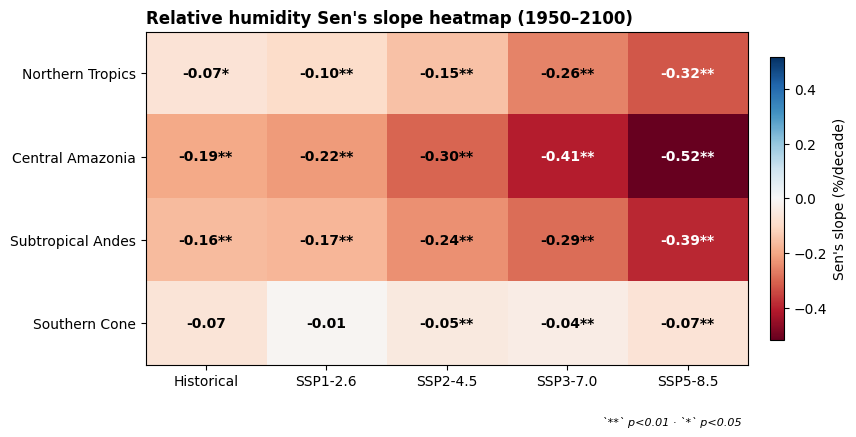

Saved: /media/volume/jay2vol/nexgddp/outputs/figures/fig5_hurs_heatmap.png


In [13]:
df_slope_hurs = compute_slope_table('hurs', 'full_1950_2100')
_, _ = heatmap_slopes(df_slope_hurs, 'hurs', '%/decade', 'Relative humidity Sen\'s slope heatmap (1950–2100)', FIG_OUT / 'fig5_hurs_heatmap.png')

## Figure 6 — Bivariate warming-drying classification map

Each pixel categorized into one of 4 states based on the sign and significance of `tas` and `hurs` Sen's slopes under SSP5-8.5 full window.

- 🟥 **Warming + drying** (most alarming): tas slope > 0 AND hurs slope < 0 (both p<0.05)
- 🟧 **Warming only:** tas slope > 0 (p<0.05), hurs not significantly drying
- 🟦 **Drying only:** hurs slope < 0 (p<0.05), tas not significantly warming
- ⬜ **No robust trend:** neither variable has p<0.05

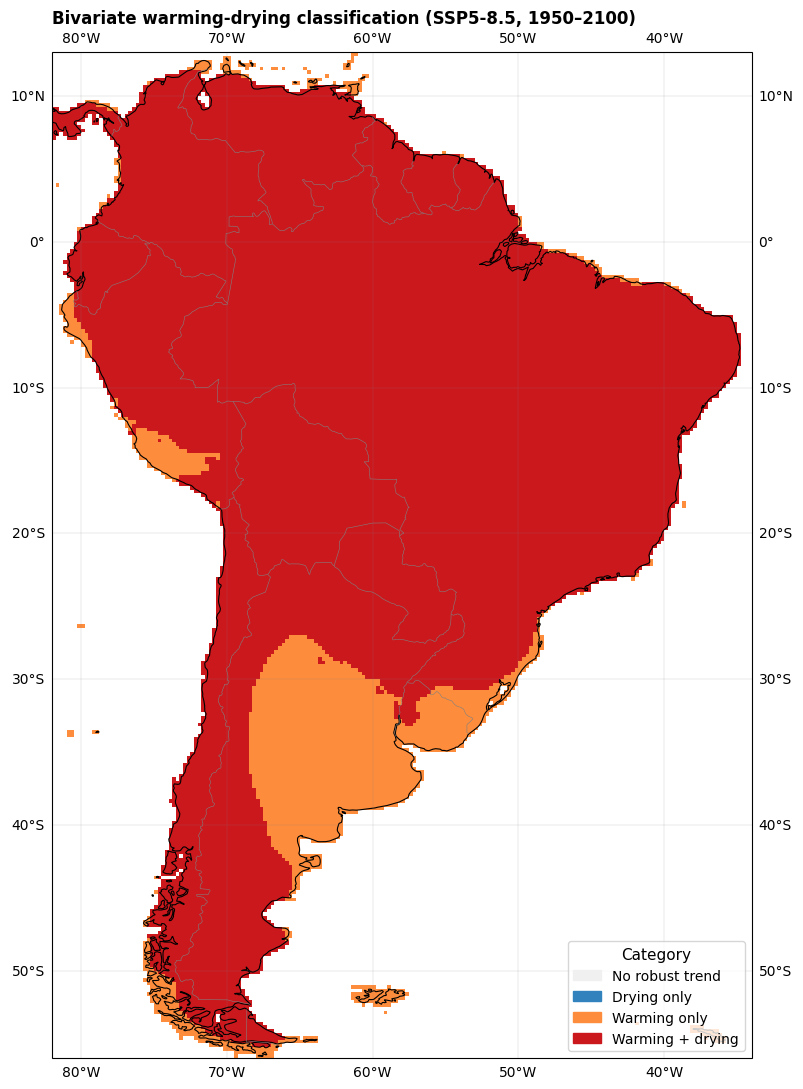

Saved: /media/volume/jay2vol/nexgddp/outputs/figures/fig6_bivariate_map.png


In [18]:
ds_tas = _load_spatial_field('tas', 'full_1950_2100', 'ssp585')
ds_hurs = _load_spatial_field('hurs', 'full_1950_2100', 'ssp585')

slope_tas = ds_tas['sen_slope'].values
pval_tas = ds_tas['mk_pvalue'].values
slope_hurs = ds_hurs['sen_slope'].values
pval_hurs = ds_hurs['mk_pvalue'].values

warming = (slope_tas > 0) & (pval_tas < 0.05)
drying = (slope_hurs < 0) & (pval_hurs < 0.05)

category = np.full(slope_tas.shape, np.nan)
category[warming & drying] = 3  # both
category[warming & ~drying] = 2  # only warming
category[~warming & drying] = 1  # only drying
category[~warming & ~drying & np.isfinite(slope_tas) & np.isfinite(slope_hurs)] = 0  # neither

cat_colors = ['#f0f0f0', '#3182bd', '#fd8d3c', '#cb181d']
cat_labels = ['No robust trend', 'Drying only', 'Warming only', 'Warming + drying']
cmap_cat = ListedColormap(cat_colors)
norm_cat = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_cat.N)

fig6, ax6 = plt.subplots(figsize=(10, 11), subplot_kw={'projection': ccrs.PlateCarree()})
ax6.set_extent(SA_EXTENT, crs=ccrs.PlateCarree())
im6 = ax6.pcolormesh(ds_tas['lon'], ds_tas['lat'], category, cmap=cmap_cat, norm=norm_cat, transform=ccrs.PlateCarree(), shading='auto')
ax6.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
ax6.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor='gray')
ax6.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4)

legend_handles = [mpatches.Patch(color=cat_colors[i], label=cat_labels[i]) for i in range(4)]
ax6.legend(handles=legend_handles, loc='lower right', fontsize=10, frameon=True, title='Category', title_fontsize=11)

ax6.set_title('Bivariate warming-drying classification (SSP5-8.5, 1950–2100)', fontsize=12, fontweight='bold', loc='left')
plt.tight_layout()
fig6.savefig(FIG_OUT / 'fig6_bivariate_map.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_OUT / "fig6_bivariate_map.png"}')

## Figure 7 — Temperature-humidity shift arrows

For each subregion: arrow from (mean tas anomaly, mean hurs anomaly) at baseline 1960–2014 to end-century 2070–2099 under SSP5-8.5. Arrow length and direction summarize joint climatic shift.

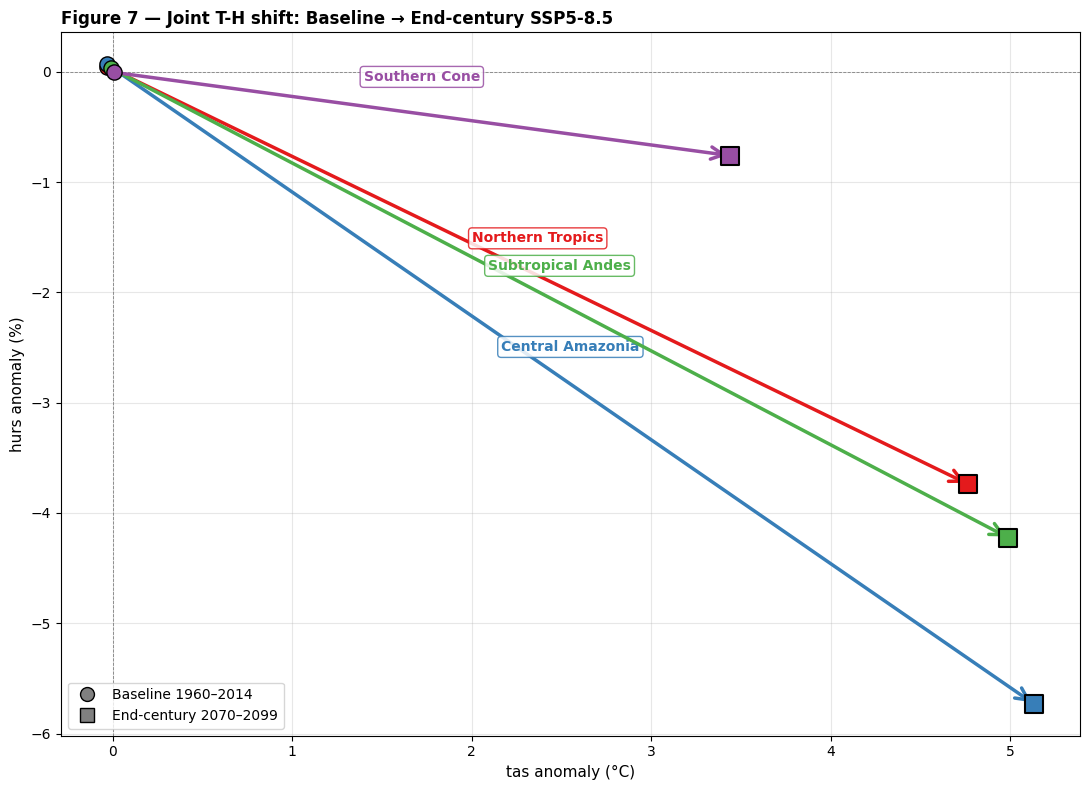

Saved: /media/volume/jay2vol/nexgddp/outputs/figures/fig7_th_arrows.png


In [10]:
def compute_shift(subregion, scenario, year_range):
    tas, hurs = al.build_monthly_paired_th(df_monthly=df_monthly, scenario=scenario, subregion=subregion, year_range=year_range, selected_models=MODELS, use_ensemble_median=True, use_anomalies=True)
    if len(tas) < 10:
        return None
    return np.mean(tas), np.mean(hurs)

shifts = {}
for sub in SUBREGION_4:
    base = compute_shift(sub, 'historical', BASELINE_PERIOD)
    fut = compute_shift(sub, 'ssp585', (2070, 2099))
    if base is not None and fut is not None:
        shifts[sub] = (base, fut)

fig7, ax7 = plt.subplots(figsize=(11, 8))
all_tas = []
all_hurs = []
for sub, (base, fut) in shifts.items():
    color = SUBREGION_BOXES[sub]['color']
    ax7.annotate('', xy=fut, xytext=base, arrowprops=dict(arrowstyle='->', color=color, lw=2.5, mutation_scale=22))
    ax7.scatter(*base, s=120, color=color, edgecolor='black', linewidth=1, zorder=5)
    ax7.scatter(*fut, s=180, color=color, edgecolor='black', linewidth=1.5, marker='s', zorder=5)
    label_x = (base[0] + fut[0]) / 2
    label_y = (base[1] + fut[1]) / 2
    ax7.text(label_x, label_y + 0.3, sub, fontsize=10, fontweight='bold', color=color, ha='center', bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor=color, alpha=0.85))
    all_tas.extend([base[0], fut[0]])
    all_hurs.extend([base[1], fut[1]])

ax7.axhline(0, color='gray', linewidth=0.6, linestyle='--')
ax7.axvline(0, color='gray', linewidth=0.6, linestyle='--')
ax7.set_xlabel('tas anomaly (°C)', fontsize=11)
ax7.set_ylabel('hurs anomaly (%)', fontsize=11)
ax7.set_title('Figure 7 — Joint T-H shift: Baseline → End-century SSP5-8.5', fontsize=12, fontweight='bold', loc='left')
ax7.grid(alpha=0.3)

legend_h = [Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=10, label='Baseline 1960–2014'),
            Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=10, label='End-century 2070–2099')]
ax7.legend(handles=legend_h, loc='lower left', fontsize=10, frameon=True)

plt.tight_layout()
fig7.savefig(FIG_OUT / 'fig7_th_arrows.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_OUT / "fig7_th_arrows.png"}')

## Figure 8 — Coupling/decoupling matrix

Spearman ρ between monthly anomalies of `tas` and `hurs` across subregions × periods × scenarios. Closes Objective II.

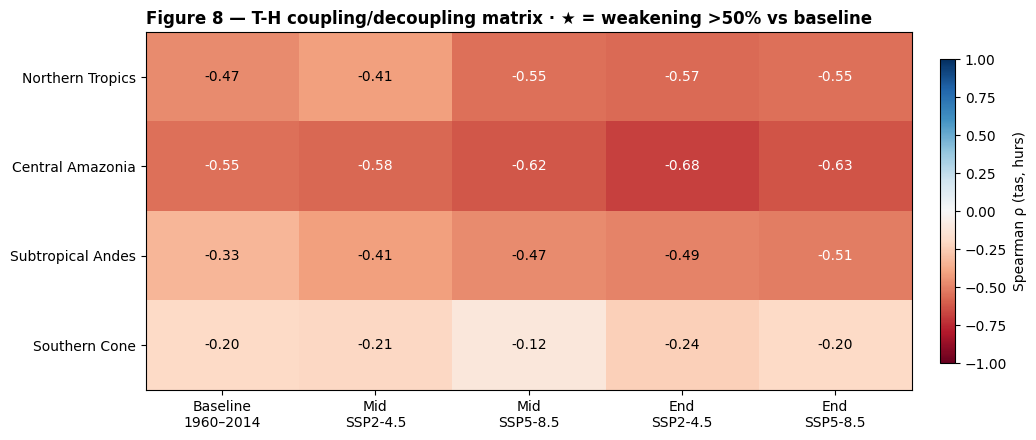

Saved: /media/volume/jay2vol/nexgddp/outputs/figures/fig8_coupling_matrix.png


In [11]:
EVO_PERIODS = [
    ('Baseline\n1960–2014', 'historical', (1960, 2014)),
    ('Mid\nSSP2-4.5',       'ssp245',     (2040, 2069)),
    ('Mid\nSSP5-8.5',       'ssp585',     (2040, 2069)),
    ('End\nSSP2-4.5',       'ssp245',     (2070, 2099)),
    ('End\nSSP5-8.5',       'ssp585',     (2070, 2099)),
]

corr_matrix = pd.DataFrame(index=SUBREGION_4, columns=[p[0] for p in EVO_PERIODS], dtype=float)
for sub in SUBREGION_4:
    for label, scen, yr in EVO_PERIODS:
        tas, hurs = al.build_monthly_paired_th(df_monthly=df_monthly, scenario=scen, subregion=sub, year_range=yr, selected_models=MODELS, use_ensemble_median=True, use_anomalies=True)
        if len(tas) >= 10:
            corr_matrix.loc[sub, label] = al.compute_all_correlations(tas, hurs)['spearman_r']

fig8, ax8 = plt.subplots(figsize=(11, 4.5))
vals8 = corr_matrix.values.astype(float)
im8 = ax8.imshow(vals8, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
ax8.set_xticks(np.arange(len(EVO_PERIODS)))
ax8.set_xticklabels([p[0] for p in EVO_PERIODS], fontsize=10)
ax8.set_yticks(np.arange(len(SUBREGION_4)))
ax8.set_yticklabels(SUBREGION_4, fontsize=10)

baseline_col = corr_matrix.iloc[:, 0]
for i, sub in enumerate(SUBREGION_4):
    baseline_abs = abs(baseline_col[sub])
    for j in range(len(EVO_PERIODS)):
        v = vals8[i, j]
        if not np.isfinite(v):
            continue
        if j > 0 and np.isfinite(baseline_abs) and baseline_abs > 0.01:
            decoupled = abs(v) < 0.5 * baseline_abs
            star = ' ★' if decoupled else ''
        else:
            star = ''
        color = 'white' if abs(v) > 0.5 else 'black'
        ax8.text(j, i, f'{v:+.2f}{star}', ha='center', va='center', fontsize=10, color=color, fontweight='bold' if star else 'normal')

cbar8 = fig8.colorbar(im8, ax=ax8, shrink=0.85, pad=0.03)
cbar8.set_label('Spearman ρ (tas, hurs)', fontsize=10)
ax8.set_title('Figure 8 — T-H coupling/decoupling matrix · ★ = weakening >50% vs baseline', fontsize=12, fontweight='bold', loc='left')
plt.tight_layout()
fig8.savefig(FIG_OUT / 'fig8_coupling_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_OUT / "fig8_coupling_matrix.png"}')

## Headline figure — Defense presentation

Single composite figure for the closing slide of the thesis defense. Combines:
- Large bivariate warming-drying map (Fig 6) on the left
- Key findings text box top-right
- Compact T-H arrows scatter (Fig 7) bottom-right
- Strip of 4 mini time series (one per subregion) at the bottom

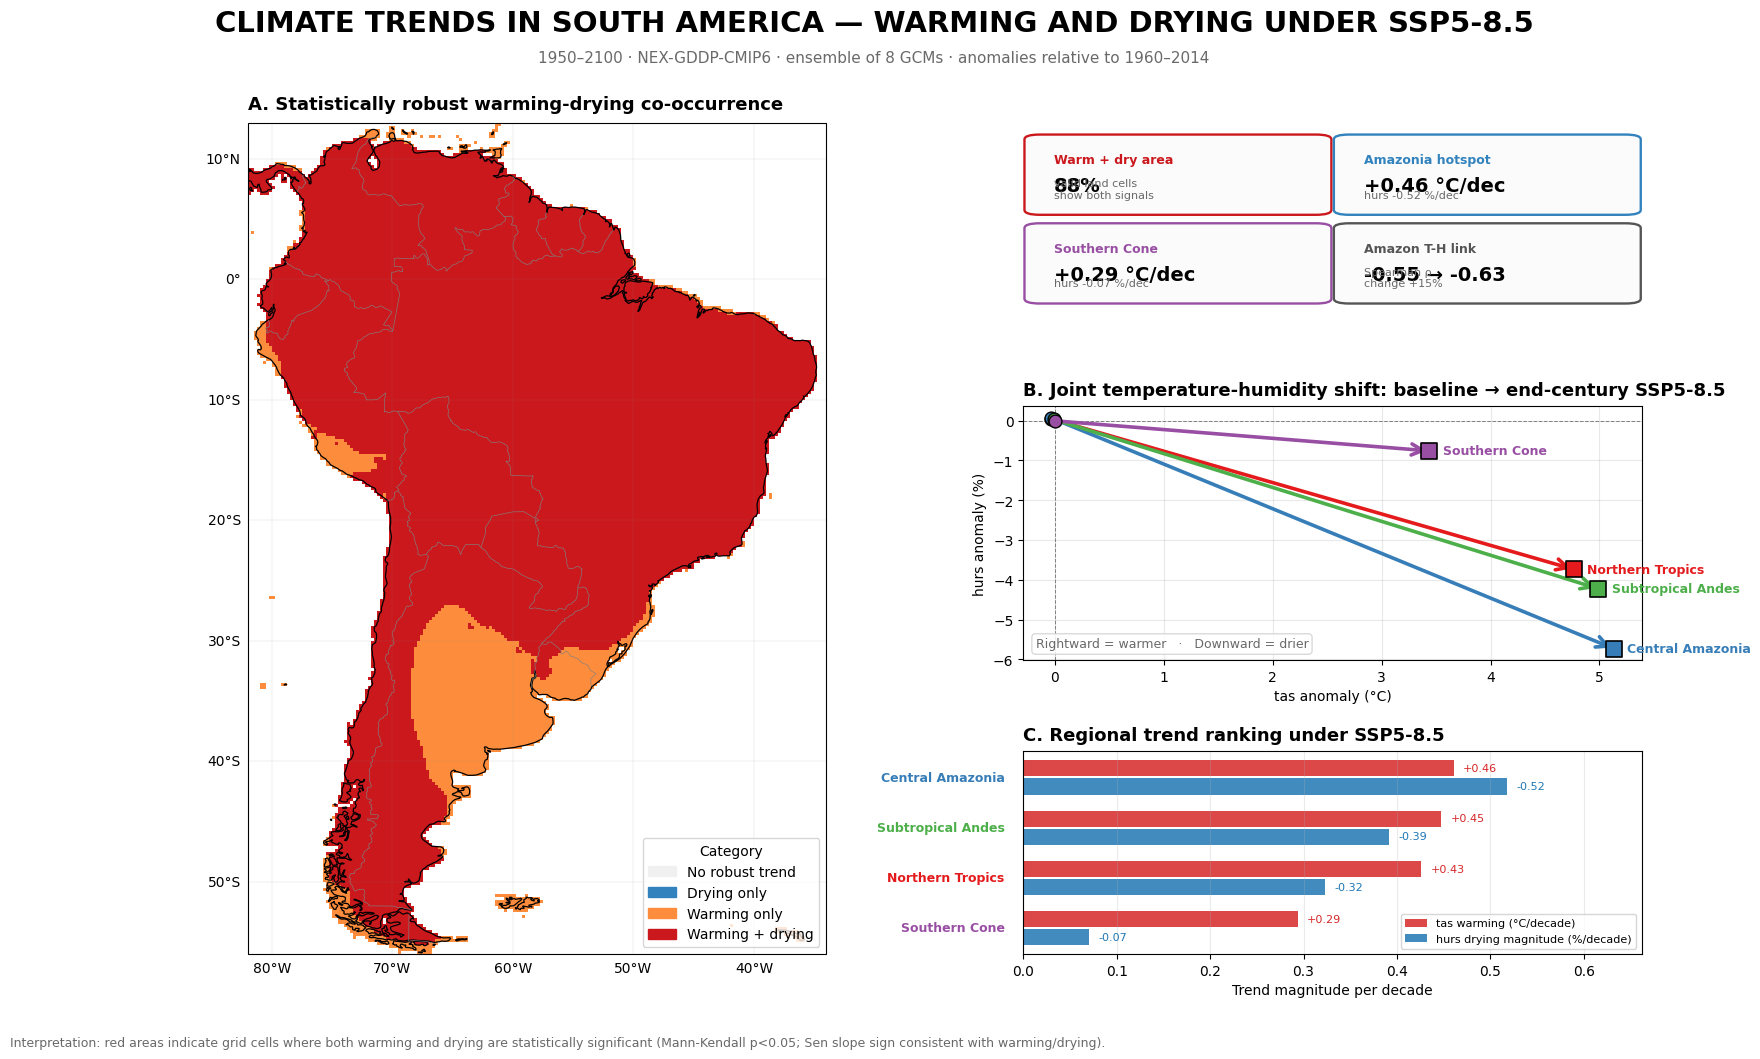

Saved: /media/volume/jay2vol/nexgddp/outputs/figures/headline_defense_v2.png


In [21]:
# =============================================================================
# Headline figure v2 — slide-oriented summary
# =============================================================================
# Assumes these objects already exist:
# ds_tas, ds_hurs, category, cmap_cat, norm_cat, cat_colors, cat_labels
# df_slope_tas, df_slope_hurs, corr_matrix, shifts
# SUBREGION_4, SUBREGION_BOXES, SA_EXTENT, FIG_OUT
# ccrs, cfeature, mpatches, np, pd, plt

from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import TwoSlopeNorm

# -----------------------------------------------------------------------------
# Helper values
# -----------------------------------------------------------------------------
valid = np.isfinite(category)
pct_both = 100 * np.sum(category == 3) / np.sum(valid)
pct_warming_only = 100 * np.sum(category == 2) / np.sum(valid)
pct_drying_only = 100 * np.sum(category == 1) / np.sum(valid)
pct_none = 100 * np.sum(category == 0) / np.sum(valid)

def _slope_value(df, subregion, scenario='ssp585'):
    row = df[(df['subregion'] == subregion) & (df['scenario'] == scenario)]
    if len(row) == 0:
        return np.nan
    return float(row['slope'].iloc[0])

tas_slopes = {sub: _slope_value(df_slope_tas, sub, 'ssp585') for sub in SUBREGION_4}
hurs_slopes = {sub: _slope_value(df_slope_hurs, sub, 'ssp585') for sub in SUBREGION_4}

amazon_tas = tas_slopes.get('Central Amazonia', np.nan)
amazon_hurs = hurs_slopes.get('Central Amazonia', np.nan)
scone_tas = tas_slopes.get('Southern Cone', np.nan)
scone_hurs = hurs_slopes.get('Southern Cone', np.nan)

amazon_baseline = corr_matrix.loc['Central Amazonia', 'Baseline\n1960–2014']
amazon_end = corr_matrix.loc['Central Amazonia', 'End\nSSP5-8.5']

# Wording as "strength change", not necessarily decoupling.
amazon_change = 100 * (abs(amazon_end) / abs(amazon_baseline) - 1) if np.isfinite(amazon_baseline) and amazon_baseline != 0 else np.nan

# -----------------------------------------------------------------------------
# Figure layout: 16:9 style for slide
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(19.2, 10.8), constrained_layout=False)
gs = GridSpec(
    3, 4,
    figure=fig,
    width_ratios=[1.35, 1.35, 1.05, 1.05],
    height_ratios=[0.95, 1.25, 1.0],
    wspace=0.35,
    hspace=0.42
)

# =============================================================================
# Title band
# =============================================================================
fig.suptitle(
    'CLIMATE TRENDS IN SOUTH AMERICA — WARMING AND DRYING UNDER SSP5-8.5',
    fontsize=21,
    fontweight='bold',
    y=0.985
)

fig.text(
    0.5, 0.94,
    '1950–2100 · NEX-GDDP-CMIP6 · ensemble of 8 GCMs · anomalies relative to 1960–2014',
    ha='center',
    va='center',
    fontsize=11,
    color='dimgray'
)

# =============================================================================
# Left: bivariate map
# =============================================================================
ax_map = fig.add_subplot(gs[0:3, 0:2], projection=ccrs.PlateCarree())

ax_map.set_extent(SA_EXTENT, crs=ccrs.PlateCarree())

ax_map.pcolormesh(
    ds_tas['lon'],
    ds_tas['lat'],
    category,
    cmap=cmap_cat,
    norm=norm_cat,
    transform=ccrs.PlateCarree(),
    shading='auto'
)

ax_map.add_feature(cfeature.COASTLINE, linewidth=0.9, edgecolor='black')
ax_map.add_feature(cfeature.BORDERS, linewidth=0.45, edgecolor='gray')

gl = ax_map.gridlines(
    draw_labels=True,
    linewidth=0.25,
    color='gray',
    alpha=0.35
)
gl.top_labels = False
gl.right_labels = False

legend_handles = [
    mpatches.Patch(color=cat_colors[i], label=cat_labels[i])
    for i in range(4)
]

ax_map.legend(
    handles=legend_handles,
    loc='lower right',
    fontsize=10,
    frameon=True,
    title='Category',
    title_fontsize=10
)

ax_map.set_title(
    'A. Statistically robust warming-drying co-occurrence',
    fontsize=13,
    fontweight='bold',
    loc='left',
    pad=10
)

# =============================================================================
# Top-right: KPI cards
# =============================================================================
ax_kpi = fig.add_subplot(gs[0, 2:4])
ax_kpi.axis('off')
ax_kpi.set_xlim(0, 1)
ax_kpi.set_ylim(0, 1)

kpi_data = [
    {
        'title': 'Warm + dry area',
        'value': f'{pct_both:.0f}%',
        'detail': 'valid land cells\nshow both signals',
        'color': '#cb181d'
    },
    {
        'title': 'Amazonia hotspot',
        'value': f'+{amazon_tas:.2f} °C/dec',
        'detail': f'hurs {amazon_hurs:+.2f} %/dec',
        'color': '#3182bd'
    },
    {
        'title': 'Southern Cone',
        'value': f'+{scone_tas:.2f} °C/dec',
        'detail': f'hurs {scone_hurs:+.2f} %/dec',
        'color': '#984ea3'
    },
    {
        'title': 'Amazon T-H link',
        'value': f'{amazon_baseline:+.2f} → {amazon_end:+.2f}',
        'detail': f'Spearman ρ\nchange {amazon_change:+.0f}%',
        'color': '#555555'
    },
]

card_positions = [
    (0.02, 0.54, 0.46, 0.38),
    (0.52, 0.54, 0.46, 0.38),
    (0.02, 0.08, 0.46, 0.38),
    (0.52, 0.08, 0.46, 0.38),
]

for kpi, (x0, y0, w, h) in zip(kpi_data, card_positions):
    rect = FancyBboxPatch(
        (x0, y0),
        w,
        h,
        boxstyle='round,pad=0.018,rounding_size=0.025',
        transform=ax_kpi.transAxes,
        facecolor='#fbfbfb',
        edgecolor=kpi['color'],
        linewidth=1.7,
        clip_on=False
    )
    ax_kpi.add_patch(rect)

    ax_kpi.text(
        x0 + 0.03,
        y0 + h - 0.08,
        kpi['title'],
        transform=ax_kpi.transAxes,
        fontsize=9,
        fontweight='bold',
        color=kpi['color'],
        va='top',
        ha='left',
        clip_on=False
    )

    ax_kpi.text(
        x0 + 0.03,
        y0 + h - 0.20,
        kpi['value'],
        transform=ax_kpi.transAxes,
        fontsize=14,
        fontweight='bold',
        color='black',
        va='top',
        ha='left',
        clip_on=False
    )

    ax_kpi.text(
        x0 + 0.03,
        y0 + 0.06,
        kpi['detail'],
        transform=ax_kpi.transAxes,
        fontsize=8,
        color='dimgray',
        va='bottom',
        ha='left',
        clip_on=False
    )

# =============================================================================
# Middle-right: joint T-H shift arrows
# =============================================================================
ax_shift = fig.add_subplot(gs[1, 2:4])

for sub, (base, fut) in shifts.items():
    color = SUBREGION_BOXES[sub]['color']

    ax_shift.annotate(
        '',
        xy=fut,
        xytext=base,
        arrowprops=dict(
            arrowstyle='->',
            color=color,
            lw=2.6,
            mutation_scale=20
        )
    )

    ax_shift.scatter(
        *base,
        s=85,
        color=color,
        edgecolor='black',
        linewidth=1.0,
        zorder=5
    )

    ax_shift.scatter(
        *fut,
        s=145,
        color=color,
        edgecolor='black',
        linewidth=1.2,
        marker='s',
        zorder=5
    )

    ax_shift.text(
        fut[0] + 0.12,
        fut[1],
        sub,
        fontsize=9,
        fontweight='bold',
        color=color,
        va='center'
    )

ax_shift.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax_shift.axvline(0, color='gray', linewidth=0.7, linestyle='--')

ax_shift.set_xlabel('tas anomaly (°C)', fontsize=10)
ax_shift.set_ylabel('hurs anomaly (%)', fontsize=10)

ax_shift.set_title(
    'B. Joint temperature-humidity shift: baseline → end-century SSP5-8.5',
    fontsize=13,
    fontweight='bold',
    loc='left',
    pad=8
)

ax_shift.grid(alpha=0.28)

# Add small interpretation label
ax_shift.text(
    0.02,
    0.05,
    'Rightward = warmer   ·   Downward = drier',
    transform=ax_shift.transAxes,
    fontsize=9,
    color='dimgray',
    bbox=dict(
        boxstyle='round,pad=0.3',
        facecolor='white',
        edgecolor='lightgray',
        alpha=0.85
    )
)

# =============================================================================
# Bottom-right: compact trend ranking
# =============================================================================
ax_rank = fig.add_subplot(gs[2, 2:4])

rank_df = pd.DataFrame({
    'subregion': SUBREGION_4,
    'tas': [tas_slopes[s] for s in SUBREGION_4],
    'hurs': [hurs_slopes[s] for s in SUBREGION_4],
})

rank_df = rank_df.sort_values('tas', ascending=True).reset_index(drop=True)
y = np.arange(len(rank_df))

# Normalize hurs for plotting on same visual panel:
# tas shown to the right, hurs decline shown to the left as absolute drying magnitude.
tas_vals = rank_df['tas'].values
dry_vals = -rank_df['hurs'].values

ax_rank.barh(
    y + 0.18,
    tas_vals,
    height=0.32,
    color='#d62728',
    alpha=0.85,
    label='tas warming (°C/decade)'
)

ax_rank.barh(
    y - 0.18,
    dry_vals,
    height=0.32,
    color='#1f77b4',
    alpha=0.85,
    label='hurs drying magnitude (%/decade)'
)

for i, row in rank_df.iterrows():
    sub = row['subregion']
    color = SUBREGION_BOXES[sub]['color']

    ax_rank.text(
        -0.02,
        i,
        sub,
        ha='right',
        va='center',
        fontsize=9,
        fontweight='bold',
        color=color
    )

    ax_rank.text(
        row['tas'] + 0.01,
        i + 0.18,
        f'{row["tas"]:+.2f}',
        ha='left',
        va='center',
        fontsize=8,
        color='#d62728'
    )

    ax_rank.text(
        -row['hurs'] + 0.01,
        i - 0.18,
        f'{row["hurs"]:+.2f}',
        ha='left',
        va='center',
        fontsize=8,
        color='#1f77b4'
    )

ax_rank.set_yticks([])
ax_rank.set_xlabel('Trend magnitude per decade', fontsize=10)
ax_rank.set_title(
    'C. Regional trend ranking under SSP5-8.5',
    fontsize=13,
    fontweight='bold',
    loc='left',
    pad=8
)

ax_rank.grid(axis='x', alpha=0.25)
ax_rank.legend(loc='lower right', fontsize=8, frameon=True)

# Keep limits readable
max_x = np.nanmax([np.nanmax(tas_vals), np.nanmax(dry_vals)])
ax_rank.set_xlim(0, max_x * 1.28)

# =============================================================================
# Footer note
# =============================================================================
fig.text(
    0.05,
    0.025,
    'Interpretation: red areas indicate grid cells where both warming and drying are statistically significant '
    '(Mann-Kendall p<0.05; Sen slope sign consistent with warming/drying).',
    ha='left',
    fontsize=9,
    color='dimgray'
)

fig.savefig(FIG_OUT / 'headline_defense_v2.png', dpi=180, bbox_inches='tight')
plt.show()

print(f'Saved: {FIG_OUT / "headline_defense_v2.png"}')